# Inspect cleaned graph JSONs

Visualize the per-node `trav_score` / `frontier_score` written by [`generate_cleaned_jsons.py`](generate_cleaned_jsons.py).

Pick a mission and scrub the frame slider. Each node from `graph_NNNNNN.json` is plotted on the matching RGB and colored by its score (viridis for traversability, magma for frontier). Nodes whose pixel landed off-image are skipped.

Set `CLEANED_ROOT` and `RGB_ROOT` below — they can point at the same directory if you ran the script with `--output-root` set to the dataset itself.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

RGB_ROOT     = Path('/home/rohang73/Desktop/ASL RGB NAV GRAPH')
CLEANED_ROOT = Path('/home/rohang73/Desktop/ASL RGB NAV GRAPH cleaned')

assert RGB_ROOT.is_dir(),     f'RGB root not found: {RGB_ROOT}'
assert CLEANED_ROOT.is_dir(), f'Cleaned root not found: {CLEANED_ROOT}'

In [2]:
def list_missions():
    return sorted(p.name for p in CLEANED_ROOT.iterdir()
                  if p.is_dir() and any(p.glob('graph_*.json')))

def list_frames(mission):
    return sorted(p.name for p in (CLEANED_ROOT / mission).glob('graph_*.json'))

def rgb_path_for(mission, graph_fname):
    idx = graph_fname.replace('graph_', '').replace('.json', '')
    return RGB_ROOT / mission / f'rgb_{idx}.png'

missions = list_missions()
assert missions, f'no cleaned missions under {CLEANED_ROOT}'
init_mission = missions[0]
print(f'{len(missions)} missions found, default: {init_mission}')

1 missions found, default: highrange_rgb_nav_graph_dataset_2024-10-01-11-47-44_mission


## Per-frame viewer

Three panels: raw RGB, nodes colored by `trav_score` (viridis), nodes colored by `frontier_score` (magma). Frontier nodes are drawn as `*`, free-space nodes as `o`. The label below the slider summarises score statistics for the current frame.

In [3]:
current_frames = []

mission_dd = widgets.Dropdown(options=missions, value=init_mission,
                              description='Mission:',
                              layout=widgets.Layout(width='90%'),
                              style={'description_width': '90px'})
frame_sl = widgets.IntSlider(min=0, max=0, step=1, value=0,
                             description='Frame idx:',
                             continuous_update=False,
                             layout=widgets.Layout(width='90%'),
                             style={'description_width': '90px'})
label = widgets.Label(value='')
out = widgets.Output()

def collect(nodes, score_key):
    xs, ys, vals, types = [], [], [], []
    for n in nodes:
        v = n.get(score_key)
        if v is None:
            continue
        px, py = n['pixel']
        xs.append(px); ys.append(py); vals.append(v); types.append(n.get('type', ''))
    return np.array(xs), np.array(ys), np.array(vals), np.array(types)

def draw_panel(ax, img, xs, ys, vals, types, cmap, title):
    ax.imshow(img); ax.set_title(title); ax.axis('off')
    if len(xs) == 0:
        return
    norm = Normalize(vmin=0.0, vmax=1.0)
    is_frontier = types == 'frontier'
    if (~is_frontier).any():
        ax.scatter(xs[~is_frontier], ys[~is_frontier], c=vals[~is_frontier],
                   cmap=cmap, norm=norm, s=36, marker='o',
                   edgecolors='black', linewidths=0.6)
    if is_frontier.any():
        ax.scatter(xs[is_frontier], ys[is_frontier], c=vals[is_frontier],
                   cmap=cmap, norm=norm, s=70, marker='*',
                   edgecolors='black', linewidths=0.7)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)

def render():
    if not current_frames:
        return
    fname = current_frames[frame_sl.value]
    mission = mission_dd.value
    rgb_p = rgb_path_for(mission, fname)
    json_p = CLEANED_ROOT / mission / fname
    img_np = np.array(Image.open(rgb_p).convert('RGB'))
    with open(json_p) as f:
        data = json.load(f)
    nodes = data.get('nodes', [])

    xs_t, ys_t, vt, types_t = collect(nodes, 'trav_score')
    xs_f, ys_f, vf, types_f = collect(nodes, 'frontier_score')

    def stats(v):
        if len(v) == 0:
            return 'n=0'
        return f'n={len(v)} min={v.min():.2f} mean={v.mean():.2f} max={v.max():.2f}'
    label.value = (f'{fname}    {img_np.shape[1]}x{img_np.shape[0]}    '
                   f'frame {frame_sl.value+1}/{len(current_frames)}    '
                   f'trav: {stats(vt)}    frontier: {stats(vf)}')

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(img_np); axes[0].set_title('RGB'); axes[0].axis('off')
        draw_panel(axes[1], img_np, xs_t, ys_t, vt, types_t, 'viridis',
                   f'trav_score (n={len(vt)})')
        draw_panel(axes[2], img_np, xs_f, ys_f, vf, types_f, 'magma',
                   f'frontier_score (n={len(vf)})')
        plt.tight_layout(); plt.show()

def on_mission_change(change):
    global current_frames
    current_frames = list_frames(change['new'])
    frame_sl.unobserve(on_frame_change, names='value')
    frame_sl.max = max(0, len(current_frames) - 1)
    frame_sl.value = 0
    frame_sl.observe(on_frame_change, names='value')
    render()

def on_frame_change(change):
    render()

current_frames = list_frames(init_mission)
frame_sl.max = max(0, len(current_frames) - 1)

mission_dd.observe(on_mission_change, names='value')
frame_sl.observe(on_frame_change, names='value')

display(widgets.VBox([mission_dd, frame_sl, label, out]))
render()

## Mission-level score histograms

Aggregates `trav_score` / `frontier_score` across all nodes in the currently-selected mission. Useful for sanity-checking that the model's score distribution is sensible (e.g. trav scores skewed towards 1.0 for `free_space` nodes).

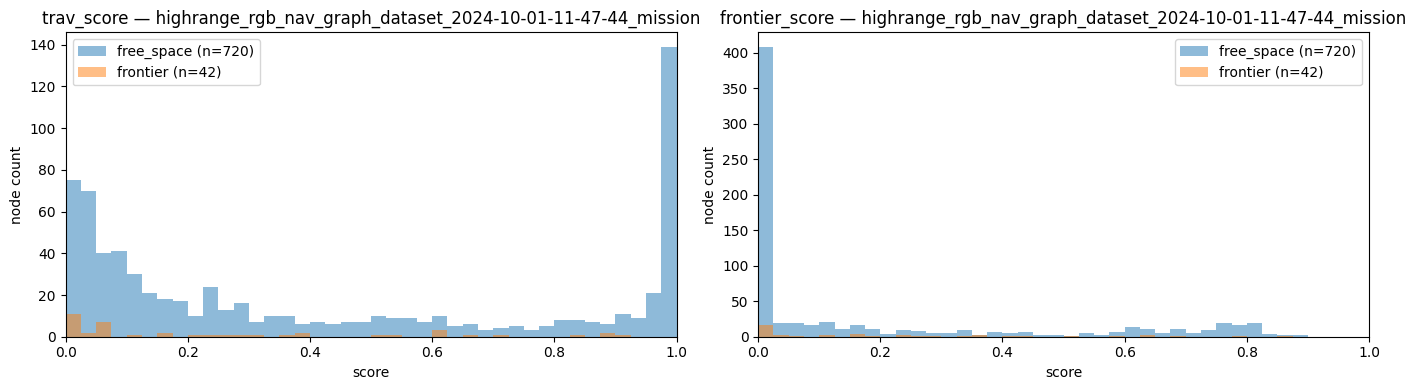

In [4]:
mission = mission_dd.value
trav_by_type = {'free_space': [], 'frontier': [], 'other': []}
front_by_type = {'free_space': [], 'frontier': [], 'other': []}
for fname in list_frames(mission):
    with open(CLEANED_ROOT / mission / fname) as f:
        for n in json.load(f).get('nodes', []):
            t = n.get('type', '')
            bucket = t if t in trav_by_type else 'other'
            if n.get('trav_score') is not None:
                trav_by_type[bucket].append(n['trav_score'])
            if n.get('frontier_score') is not None:
                front_by_type[bucket].append(n['frontier_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, scores, title in [
    (axes[0], trav_by_type,  f'trav_score — {mission}'),
    (axes[1], front_by_type, f'frontier_score — {mission}'),
]:
    for bucket, vals in scores.items():
        if vals:
            ax.hist(vals, bins=40, range=(0, 1), alpha=0.5,
                    label=f'{bucket} (n={len(vals)})')
    ax.set_xlim(0, 1); ax.set_xlabel('score'); ax.set_ylabel('node count')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()